<a href="https://colab.research.google.com/github/Benja-Diaz/EP1-Deep-Learning/blob/main/Evaluacion_Parcial_1_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Evaluación Parcial N° 1-  Fundamentos de Deep Learning_ 009V_OLS**  


Maria Jose Alvarez

Benjamin Diaz



Nuestro objetivo será implementar una Red Neuronal Artificial Multicapa (MLP) utilizando Python y TensorFlow/Keras para resolver un problema de clasificación a partir del conjunto de datos proporcionado.

Durante el desarrollo se realizará la exploración y preprocesamiento de los datos, el diseño y entrenamiento de una arquitectura MLP y la evaluación de distintas configuraciones del modelo.

Analizaremos el efecto de diferentes hiperparámetros y técnicas de optimización sobre el desempeño de la red, utilizando métricas de clasificación como Accuracy, Precision, Recall y F1-Score.

Finalmente, compararemos los resultados obtenidos para seleccionar y justificar una configuración adecuada del modelo.

# 1. Preparación

Vamos a importar las librerías necesarias para la carga, exploración, preprocesamiento y visualización de los datos.

In [401]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. Carga y exploración inicial de los datos

Antes de realizar cualquier transformación, analizaremos la estructura original del conjunto de datos.

Esta exploración permitirá conocer sus dimensiones, variables, tipos de datos y contenido general antes de tomar decisiones de preprocesamiento.

En esta etapa no se modificarán los datos, ya que primero es necesario identificar posibles problemas como valores nulos, registros duplicados, escalas diferentes o valores atípicos.

In [402]:
df = pd.read_csv('/content/dataset.csv')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 2660
Columnas: 13


In [403]:
df.head()

,edad,tiempo_sesion,paginas_vistas,historial_compras,descuentos_usados,dispositivo_movil,valoracion_media,frecuencia_devolucion,clics_publicidad,interaccion_redes,interes_tecnologia,interes_moda,interes_deportes
0,0.473008,-2.015216,-0.617204,1.912964,1.104647,7.124469,-2.477666,-0.135015,-0.542116,-0.761970,0,1,1
1,0.578279,0.967299,1.443789,0.993972,-0.620909,-0.667771,-1.835993,-4.181187,1.502827,-1.455356,1,0,0
2,0.101556,-0.773922,-0.164761,0.464491,2.402765,-1.150528,0.157838,0.322459,-0.268127,0.219723,1,0,1
3,-0.091381,-1.361323,2.749614,-1.941579,-0.092780,-3.207476,-1.517199,1.829656,0.880481,-0.589325,0,1,0
4,1.953657,1.248484,1.212312,0.515772,-0.559830,-0.907930,113.927263,1.052013,0.281696,NaN,1,0,1


## 2.1 Estructura y tipos de datos

Antes de realizar el preprocesamiento, se revisará la estructura del conjunto de datos y el tipo de información almacenada en cada variable.

Identificaremos las variables cargadas, sus tipos de datos y si es necesario realizar alguna modificación.

In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2660 entries, 0 to 2659
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   edad                   2527 non-null   float64
 1   tiempo_sesion          2527 non-null   float64
 2   paginas_vistas         2527 non-null   float64
 3   historial_compras      2527 non-null   float64
 4   descuentos_usados      2527 non-null   float64
 5   dispositivo_movil      2527 non-null   float64
 6   valoracion_media       2527 non-null   float64
 7   frecuencia_devolucion  2527 non-null   float64
 8   clics_publicidad       2527 non-null   float64
 9   interaccion_redes      2527 non-null   float64
 10  interes_tecnologia     2660 non-null   int64  
 11  interes_moda           2660 non-null   int64  
 12  interes_deportes       2660 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 270.3 KB


## 2.2 Análisis de valores nulos

Los valores nulos pueden afectar el entrenamiento, vamos a identificar y cuantificar estos valores en primera instancia, para poder evaluar que haremos con ellos, antes de construir el modelo.

Revisaremos valores y porcentaje de nulos por columna.

In [405]:
nulos = df.isnull().sum()

porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

#resumen.

tabla_nulos = pd.DataFrame({
    'Cantidad de nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

tabla_nulos

,Cantidad de nulos,Porcentaje (%)
edad,133,5.0
tiempo_sesion,133,5.0
paginas_vistas,133,5.0
historial_compras,133,5.0
descuentos_usados,133,5.0
dispositivo_movil,133,5.0
valoracion_media,133,5.0
frecuencia_devolucion,133,5.0
clics_publicidad,133,5.0
interaccion_redes,133,5.0


## 2.3 Análisis de registros duplicados

Revisaremos si tenemos filas duplicadas.

Los registros duplicados pueden introducir información repetida y afectar la representación de los datos durante el entrenamiento. Por esta razón, primero se realizará una revisión antes de decidir si es necesario eliminar algún registro.

In [406]:
duplicados = df.duplicated().sum()

print(f"Cantidad de registros duplicados: {duplicados}")

Cantidad de registros duplicados: 0


## 2.4 Estadística descriptiva


Esta información nos permite identificar diferencias importantes entre las escalas de las variables y posibles valores extremos.

Vamos a conocer su distribución general, rango de valores, tendencia central y dispersión.



In [407]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,2527.0,0.028644,2.864742,-98.148405,-0.705508,-0.001330,0.732280,70.526039
tiempo_sesion,2527.0,-0.509256,11.663665,-407.855167,-1.254657,-0.057786,0.978884,108.165792
paginas_vistas,2527.0,-0.669196,25.176848,-880.978886,-1.198387,0.073469,1.302754,325.953770
historial_compras,2527.0,-0.071617,9.287414,-167.607977,-2.385029,-0.081522,1.467249,324.435524
descuentos_usados,2527.0,-1.495201,45.253356,-1584.224648,-1.734092,-0.646663,0.438737,1135.567267
dispositivo_movil,2527.0,-0.962142,3.577355,-89.608936,-1.871420,-0.981453,-0.118926,122.427075
valoracion_media,2527.0,0.496815,17.082451,-221.057319,-1.193552,-0.111521,1.091570,597.603451
frecuencia_devolucion,2527.0,0.462469,4.881745,-121.327790,-0.645409,0.552520,1.632515,170.020681
clics_publicidad,2527.0,-0.010479,1.195890,-9.717513,-0.692452,-0.006665,0.641638,11.623093
interaccion_redes,2527.0,0.316455,11.503382,-429.825192,-0.716109,0.341631,1.488356,309.445769


El análisis evidencia diferencias importantes entre los valores centrales y los valores mínimos y máximos de varias variables predictoras.

Las variables de entrada presentan valores centrales cercanos a cero. Sin embargo, algunas muestran valores mínimos y máximos considerablemente alejados de sus cuartiles. Esto sugiere la posible presencia de valores atípicos, los cuales deben ser analizados antes de tomar decisiones de preprocesamiento.

Además, las variables objetivo **interes_tecnologia**, **interes_moda** e **interes_deportes** presentan valores binarios y no contienen datos faltantes.

Antes de realizar el entrenamiento, se analizará específicamente la presencia de valores atípicos en las variables predictoras, a raíz de lo observado anteriormente.

In [408]:
# Variables objetivo- cuantos 0 y 1 tenemos en cada una de las variables

columnas_objetivo = [
    'interes_tecnologia',
    'interes_moda',
    'interes_deportes'
]

for columna in columnas_objetivo:
    print(f"\nDistribución de {columna}:")
    print(df[columna].value_counts())

    combinaciones_y = (
    df[columnas_objetivo]
    .value_counts()
    .reset_index(name='cantidad')
)

combinaciones_y


Distribución de interes_tecnologia:
interes_tecnologia
0    1504
1    1156
Name: count, dtype: int64

Distribución de interes_moda:
interes_moda
0    1497
1    1163
Name: count, dtype: int64

Distribución de interes_deportes:
interes_deportes
0    1507
1    1153
Name: count, dtype: int64


,interes_tecnologia,interes_moda,interes_deportes,cantidad
0,1,1,0,393
1,0,0,1,392
2,0,0,0,380
3,1,0,0,372
4,0,1,1,370
5,0,1,0,362
6,1,0,1,353
7,1,1,1,38


Las variables objetivo están relativamente equilibradas entre las clases 0 y 1.

También podemos observar que las categorías no son excluyentes, ya que una misma observación puede tener interés en más de una categoría al mismo tiempo. Incluso existen casos donde no se presenta interés en ninguna de ellas.

Por esto, estamos frente a un problema de clasificación multietiqueta.

Esto se tendrá en cuenta más adelante al momento de definir la capa de salida y la función de pérdida del modelo.

## 2.6 Análisis de valores atípicos

El análisis descriptivo mostró diferencias considerables entre los cuartiles y los valores mínimos y máximos de varias variables predictoras.

Para identificar cuantitativamente posibles valores atípicos se utilizará el método del rango intercuartílico (IQR).

Los valores atípicos serán únicamente identificados y cuantificados por el momento.

In [409]:
# Variables (X) predictoras
columnas_x = [
    'edad',
    'tiempo_sesion',
    'paginas_vistas',
    'historial_compras',
    'descuentos_usados',
    'dispositivo_movil',
    'valoracion_media',
    'frecuencia_devolucion',
    'clics_publicidad',
    'interaccion_redes'
]

# Variables (Y) objetivo
columnas_y = [
    'interes_tecnologia',
    'interes_moda',
    'interes_deportes'
]

print(f"Variables predictoras (X): {len(columnas_x)}")
print(f"Variables objetivo (Y): {len(columnas_y)}")

Variables predictoras (X): 10
Variables objetivo (Y): 3


In [410]:
# Conteo de valores atípicos mediante el método IQR
resumen_outliers = []

for columna in columnas_x:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ][columna]

    resumen_outliers.append({
        'Variable': columna,
        'Límite inferior': round(limite_inferior, 3),
        'Límite superior': round(limite_superior, 3),
        'Cantidad de outliers': len(outliers),
        'Porcentaje (%)': round((len(outliers) / df[columna].notna().sum()) * 100, 2)
    })

tabla_outliers = pd.DataFrame(resumen_outliers)

tabla_outliers

,Variable,Límite inferior,Límite superior,Cantidad de outliers,Porcentaje (%)
0,edad,-2.862,2.889,39,1.54
1,tiempo_sesion,-4.605,4.329,36,1.42
2,paginas_vistas,-4.950,5.054,38,1.50
3,historial_compras,-8.163,7.246,14,0.55
4,descuentos_usados,-4.993,3.698,48,1.90
5,dispositivo_movil,-4.500,2.510,41,1.62
6,valoracion_media,-4.621,4.519,36,1.42
7,frecuencia_devolucion,-4.062,5.049,58,2.30
8,clics_publicidad,-2.694,2.643,43,1.70
9,interaccion_redes,-4.023,4.795,51,2.02


### Interpretación del análisis de valores atípicos

El metodo realizado nos permitio revisar que tenemos valores atipicos en todas las variables X ( predictoras), la proporcion es relativamente baja, sin embargo, los analisis anteriores nos dicen que hay algunos valores bastante alejados de los rangos centrales de sus respectivas variables.

la presencia de un valor atipico no indica necesariamente que el valor sea incorrecto basado en esto, no eliminaremos inmediatamente estos, revisaremos con mas detalle con otros analisis.

## 2.7 Análisis del patrón de valores faltantes

El analisis inicial nos mostró que tenemos valores faltantes en las variables.

No podemos eliminarlas porque si, ya que estas pueden ser utiles y se deben tratar de diferentes maneras, antes de seleccionar una estrategia de tratamiento, se analizará cómo se distribuyen estos valores entre las observaciones.

Esto permite determinar si los datos faltantes se concentran en un mismo grupo de registros o si aparecen distribuidos entre diferentes filas.

In [411]:
# Cantidad de valores nulos de X presentes en cada fila
nulos_por_fila = df[columnas_x].isnull().sum(axis=1)

print("Distribución de valores nulos por fila:")
print(nulos_por_fila.value_counts().sort_index())

Distribución de valores nulos por fila:
0    1604
1     813
2     212
3      31
Name: count, dtype: int64


In [412]:
# Resumen datos faltantes

filas_con_nulos = (nulos_por_fila > 0).sum()
filas_completas = (nulos_por_fila == 0).sum()

print(f"Total de registros: {len(df)}")
print(f"Filas completas en X: {filas_completas}")
print(f"Filas con al menos un valor nulo en X: {filas_con_nulos}")

print(
    f"Porcentaje de filas afectadas: "
    f"{(filas_con_nulos / len(df)) * 100:.2f}%"
)

#aqui me falto un parentesis le pedi a ia que me ayudara porque no encontraba el error

Total de registros: 2660
Filas completas en X: 1604
Filas con al menos un valor nulo en X: 1056
Porcentaje de filas afectadas: 39.70%


# 2.7 Patrón de valores faltantes

El 39,70% de las observaciones presenta algún dato faltante. La mayoría de las filas afectadas contiene solamente un valor nulo (813 registros), mientras que 212 registros presentan dos valores nulos y 31 presentan tres.

Aunque cada variable predictora contiene individualmente aproximadamente un 5% de valores faltantes, estos se encuentran distribuidos entre diferentes observaciones.

Por esta razón, eliminar todas las filas que contengan valores nulos implicaría descartar aproximadamente el 39,70% del conjunto de datos, provocando una pérdida considerable.

se evaluará una estrategia de imputación para conservar la mayor cantidad posible de observaciones.


## 2.8 Visualización de valores atípicos

Para complementar el análisis mediante IQR, se utilizarán boxplots que permitan observar la distribución de las variables predictoras y la presencia de valores alejados de los rangos centrales.

Esto permitirá respaldar las decisiones posteriores relacionadas con el tratamiento de valores extremos.

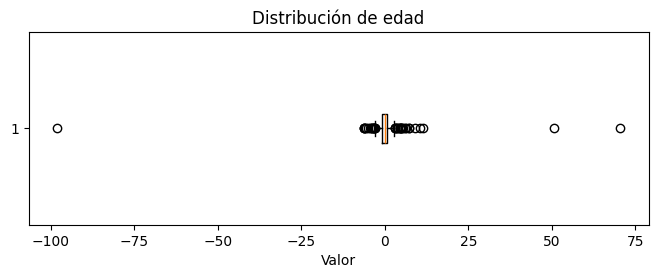

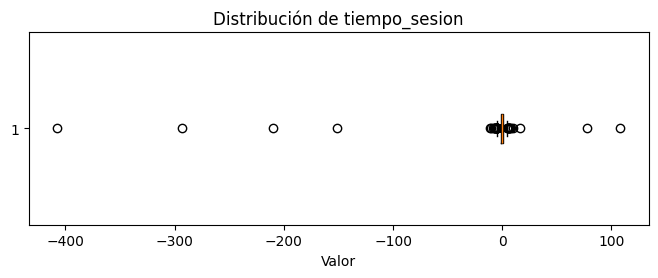

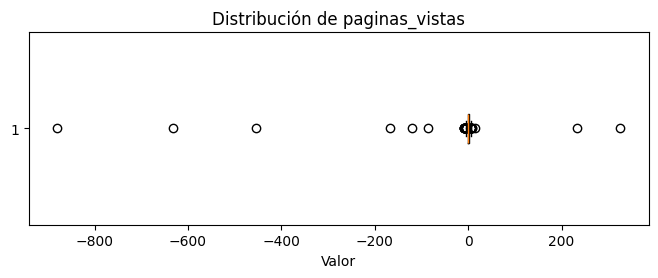

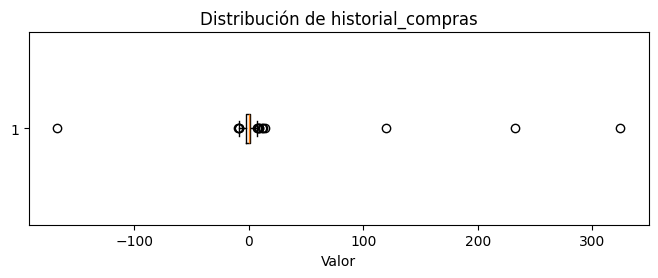

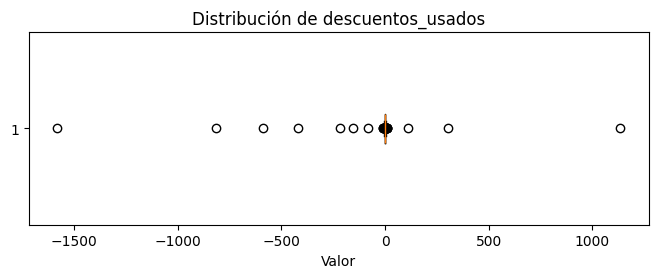

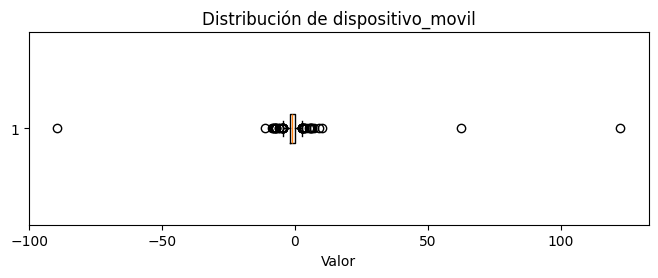

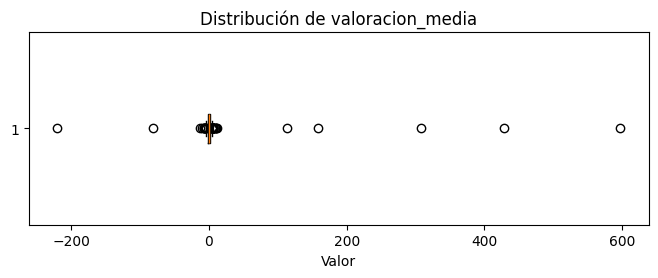

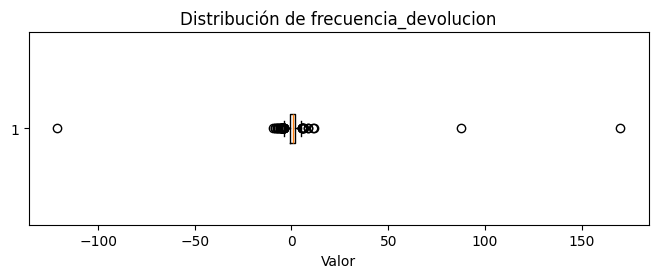

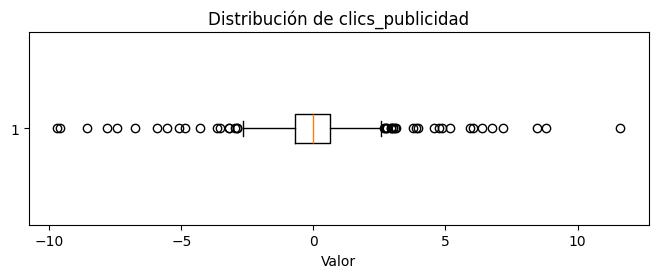

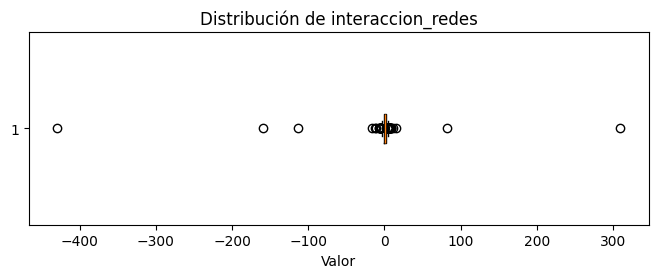

In [413]:
# Boxplots de las variables x ( predictoras)

for columna in columnas_x:
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(
        df[columna].dropna(),
        vert=False
    )

    plt.title(f'Distribución de {columna}')
    plt.xlabel('Valor')
    plt.show()

###  Valores atípicos

Los boxplot confirman la presencia de valores alejados de los rangos centrales en las variables predictoras.

En varias variables, como **paginas_vistas**, **descuentos_usados**, **valoracion_media** e **interaccion_redes**, hay valores extremos considerablemente separados de la mayor concentración de los datos.

Sin embargo, el comportamiento no es igual en todas las variables. En **clics_publicidad**, por ejemplo, los valores identificados mediante el criterio IQR presentan una distribución más continua alrededor del rango central.

Por lo tanto, no resulta conveniente eliminar automáticamente todos los registros identificados como atípicos únicamente mediante el criterio IQR. Se evaluará un tratamiento que reduzca la influencia de los valores extremos sin provocar una pérdida innecesaria de observaciones.

# 3. Preparación de los datos para el modelamiento

Luego de realizar el análisis exploratorio, prepararemos los datos para el entrenamiento de la red neuronal.

Las diez variables predictoras corresponden a las características de entrada (X), mientras que las variables **interes_tecnologia**, **interes_moda** e **interes_deportes** corresponden a las variables objetivo (Y).

Debido a que las variables objetivo pueden tomar el valor 1 simultáneamente, el problema corresponde a una clasificación multietiqueta.

In [414]:
# Separación entre variables predictoras (x) y variables objetivo (y)

X = df[columnas_x].copy()
y = df[columnas_y].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (2660, 10)
Dimensiones de y: (2660, 3)


## 3.1 División en entrenamiento, validación y prueba

El conjunto de datos se dividirá en tres subconjuntos:

- **70% entrenamiento:** utilizado para que la red neuronal aprenda sus parámetros.
- **15% validación:** utilizado para evaluar y comparar configuraciones durante el desarrollo del modelo.
- **15% prueba:** reservado para evaluar el desempeño final del modelo seleccionado sobre datos no utilizados durante el entrenamiento.

Esta separación permite evaluar la capacidad de generalización del modelo y evita utilizar el conjunto de prueba durante la selección de hiperparámetros.

In [415]:
from sklearn.model_selection import train_test_split


# Primera división: 70% entrenamiento y 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Segunda división: el 30% temporal se divide en
# 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:   ", X_val.shape, y_val.shape)
print("Prueba:       ", X_test.shape, y_test.shape)

Entrenamiento: (1862, 10) (1862, 3)
Validación:    (399, 10) (399, 3)
Prueba:        (399, 10) (399, 3)


## 3.2 Verificación de la distribución de las variables objetivo

Después de realizar la división del conjunto de datos, verificamos la proporción de casos positivos de cada variable objetivo en los conjuntos de entrenamiento, validación y prueba.

Con esto comprobamos que la división aleatoria no haya generado diferencias importantes en la distribución de las etiquetas entre los subconjuntos.

In [416]:
# Comparación de la proporción de casos positivos (valor 1)
# en entrenamiento, validación y prueba

distribucion_y = pd.DataFrame({
    'Entrenamiento (%)': y_train.mean() * 100,
    'Validación (%)': y_val.mean() * 100,
    'Prueba (%)': y_test.mean() * 100
})

distribucion_y.round(2)

,Entrenamiento (%),Validación (%),Prueba (%)
interes_tecnologia,43.18,42.11,46.12
interes_moda,44.04,44.11,41.85
interes_deportes,42.91,44.11,44.61


###  Distribución de las etiquetas

Las proporciones de casos positivos de las tres variables objetivo se mantienen relativamente similares entre los conjuntos de entrenamiento, validación y prueba.

Las diferencias son pequeñas y esperables debido a la división aleatoria de los datos. No se identifican desbalances importantes entre los subconjuntos, por lo que se mantiene la división realizada.

Así, los tres conjuntos conservan una representación similar de las variables objetivo y pueden utilizarse para las siguientes etapas del modelamiento.

## 3.3 Tratamiento de valores faltantes

El análisis exploratorio mostró que eliminar todas las observaciones que presentan valores faltantes significaría eliminar aproximadamente el 39,70% de los datos.

Por esta razón, usaremos imputación mediante la mediana. Esta medida es robusta frente a valores extremos, característica relevante considerando los outliers identificados durante el análisis exploratorio.

Para evitar fuga de información (data leakage), los valores utilizados para realizar la imputación serán calculados exclusivamente a partir del conjunto de entrenamiento. Después, la misma transformación la aplicaremos a los conjuntos de validación y prueba.

In [417]:
from sklearn.impute import SimpleImputer

# Imputador utilizando la mediana
imputador = SimpleImputer(strategy='median')

# La mediana se calcula con los datos de entrenamiento
X_train_imp = imputador.fit_transform(X_train)

# Se utilizan las mismas medianas para validación y prueba
X_val_imp = imputador.transform(X_val)
X_test_imp = imputador.transform(X_test)

In [418]:
# Conversión nuevamente a DataFrame para conservar
# los nombres de las variables

X_train_imp = pd.DataFrame(
    X_train_imp,
    columns=columnas_x,
    index=X_train.index
)

X_val_imp = pd.DataFrame(
    X_val_imp,
    columns=columnas_x,
    index=X_val.index
)

X_test_imp = pd.DataFrame(
    X_test_imp,
    columns=columnas_x,
    index=X_test.index
)

In [419]:
print("Valores nulos después de la imputación:")

print("\nEntrenamiento:")
print(np.isnan(X_train_imp).sum().sum())

print("\nValidación:")
print(np.isnan(X_val_imp).sum().sum())

print("\nPrueba:")
print(np.isnan(X_test_imp).sum().sum())

Valores nulos después de la imputación:

Entrenamiento:
0

Validación:
0

Prueba:
0


In [420]:
medianas_train = pd.Series(
    imputador.statistics_,
    index=columnas_x,
    name='Mediana entrenamiento'
)

medianas_train

,Mediana entrenamiento
edad,-0.009439
tiempo_sesion,-0.060908
paginas_vistas,0.021373
historial_compras,-0.050484
descuentos_usados,-0.705116
dispositivo_movil,-1.004752
valoracion_media,-0.111761
frecuencia_devolucion,0.527034
clics_publicidad,-0.028656
interaccion_redes,0.340374


### Resultado de la imputación

La imputación mediante la mediana permitió eliminar completamente los valores faltantes de los conjuntos de entrenamiento, validación y prueba sin eliminar observaciones.

Las medianas utilizadas fueron calculadas exclusivamente a partir del conjunto de entrenamiento y posteriormente aplicadas a los otros subconjuntos. De esta forma, se evita incorporar información proveniente de validación o prueba durante el preprocesamiento.

Después de la transformación, los tres conjuntos presentan cero valores nulos.

## 3.4 Evaluación inicial del escalado con RobustScaler

Las redes neuronales se benefician de trabajar con variables en escalas comparables, ya que diferencias importantes entre magnitudes pueden afectar la estabilidad del proceso de optimización.

Durante el análisis exploratorio se identificaron valores extremos en varias variables predictoras. Por esta razón, se utilizará **RobustScaler**, método de escalado basado en la mediana y el rango intercuartílico (IQR), lo que lo hace menos sensible a valores atípicos que métodos basados en la media y desviación estándar.

Al igual que en la imputación, el escalador será ajustado exclusivamente con el conjunto de entrenamiento y posteriormente aplicado a validación y prueba, evitando fuga de información.

In [421]:
from sklearn.preprocessing import RobustScaler

# Creación del escalador
scaler = RobustScaler()

# El escalador aprende únicamente desde entrenamiento
X_train_scaled = scaler.fit_transform(X_train_imp)

# Se aplica la misma transformación a validación y prueba
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

In [422]:
# Conversión a DataFrame para conservar los nombres de las variables

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=columnas_x,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=columnas_x,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=columnas_x,
    index=X_test.index
)

In [423]:
# Estadísticas del conjunto de entrenamiento después del escalado
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,1862.0,0.060667,1.725600,-4.697212,-0.491386,0.0,0.508614,52.650034
tiempo_sesion,1862.0,-0.260274,6.255981,-188.417296,-0.535033,0.0,0.464967,50.005074
paginas_vistas,1862.0,-0.411767,12.397670,-372.733984,-0.481453,0.0,0.518547,137.895625
historial_compras,1862.0,0.014080,2.956543,-46.323127,-0.616857,0.0,0.383143,89.707755
descuentos_usados,1862.0,-0.583071,26.215007,-787.614214,-0.511822,0.0,0.488178,565.161504
dispositivo_movil,1862.0,0.057355,2.167993,-4.744618,-0.501163,0.0,0.498837,76.398596
valoracion_media,1862.0,0.378940,9.481308,-105.437318,-0.484403,0.0,0.515597,285.235374
frecuencia_devolucion,1862.0,-0.029856,2.623439,-57.399761,-0.506025,0.0,0.493975,79.840047
clics_publicidad,1862.0,0.002367,0.935365,-7.802727,-0.509795,0.0,0.490205,9.383501
interaccion_redes,1862.0,-0.029705,6.395559,-206.129841,-0.478192,0.0,0.521808,148.119354


In [424]:
print("Dimensiones finales:")
print("X_train:", X_train_scaled.shape)
print("X_val:  ", X_val_scaled.shape)
print("X_test: ", X_test_scaled.shape)

print("\nValores nulos:")
print("Train:", X_train_scaled.isnull().sum().sum())
print("Val:  ", X_val_scaled.isnull().sum().sum())
print("Test: ", X_test_scaled.isnull().sum().sum())

Dimensiones finales:
X_train: (1862, 10)
X_val:   (399, 10)
X_test:  (399, 10)

Valores nulos:
Train: 0
Val:   0
Test:  0


In [425]:
# Estadísticas después de aplicar RobustScaler
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,1862.0,0.060667,1.725600,-4.697212,-0.491386,0.0,0.508614,52.650034
tiempo_sesion,1862.0,-0.260274,6.255981,-188.417296,-0.535033,0.0,0.464967,50.005074
paginas_vistas,1862.0,-0.411767,12.397670,-372.733984,-0.481453,0.0,0.518547,137.895625
historial_compras,1862.0,0.014080,2.956543,-46.323127,-0.616857,0.0,0.383143,89.707755
descuentos_usados,1862.0,-0.583071,26.215007,-787.614214,-0.511822,0.0,0.488178,565.161504
dispositivo_movil,1862.0,0.057355,2.167993,-4.744618,-0.501163,0.0,0.498837,76.398596
valoracion_media,1862.0,0.378940,9.481308,-105.437318,-0.484403,0.0,0.515597,285.235374
frecuencia_devolucion,1862.0,-0.029856,2.623439,-57.399761,-0.506025,0.0,0.493975,79.840047
clics_publicidad,1862.0,0.002367,0.935365,-7.802727,-0.509795,0.0,0.490205,9.383501
interaccion_redes,1862.0,-0.029705,6.395559,-206.129841,-0.478192,0.0,0.521808,148.119354



Después de aplicar **RobustScaler**, las medianas de las variables predictoras se encuentran centradas en 0 y el rango central de los datos presenta una escala comparable entre las distintas características.

Sin embargo, algunos valores extremos continúan considerablemente alejados del rango central. Esto ocurre porque **RobustScaler** reduce la influencia de los valores atípicos sobre el cálculo de la escala, pero no los elimina ni modifica directamente.

Debido a la magnitud de algunos valores extremos, se aplicará un procedimiento de clipping para limitar su influencia durante el entrenamiento de la red neuronal, sin eliminar observaciones.

## 3.5 Tratamiento de valores extremos

Para reducir la influencia de valores extremadamente alejados sin eliminar observaciones, se aplicará un procedimiento de clipping basado en el rango intercuartílico (IQR).

Los límites serán calculados exclusivamente utilizando el conjunto de entrenamiento. Los valores inferiores o superiores a dichos límites serán reemplazados por el límite correspondiente.

Posteriormente, los mismos límites obtenidos desde entrenamiento serán aplicados a los conjuntos de validación y prueba, evitando fuga de información.

In [426]:
# Cálculo de límites IQR utilizando exclusivamente entrenamiento

Q1_train = X_train_imp.quantile(0.25)
Q3_train = X_train_imp.quantile(0.75)

IQR_train = Q3_train - Q1_train

limite_inferior = Q1_train - 1.5 * IQR_train
limite_superior = Q3_train + 1.5 * IQR_train

limites_outliers = pd.DataFrame({
    'Límite inferior': limite_inferior,
    'Límite superior': limite_superior
})

limites_outliers.round(3)

,Límite inferior,Límite superior
edad,-2.677,2.682
tiempo_sesion,-4.465,4.192
paginas_vistas,-4.662,4.792
historial_compras,-7.707,6.761
descuentos_usados,-4.750,3.292
dispositivo_movil,-4.238,2.225
valoracion_media,-4.270,4.112
frecuencia_devolucion,-3.732,4.760
clics_publicidad,-2.524,2.443
interaccion_redes,-3.788,4.560


In [427]:
# Aplicación de los límites calculados con el conjunto de entrenamiento

X_train_clip = X_train_imp.clip(
    lower=limite_inferior,
    upper=limite_superior,
    axis=1
)

X_val_clip = X_val_imp.clip(
    lower=limite_inferior,
    upper=limite_superior,
    axis=1
)

X_test_clip = X_test_imp.clip(
    lower=limite_inferior,
    upper=limite_superior,
    axis=1
)

In [428]:
# Nuevo escalado después del tratamiento de valores extremos

scaler_final = RobustScaler()

X_train_final = scaler_final.fit_transform(X_train_clip)
X_val_final = scaler_final.transform(X_val_clip)
X_test_final = scaler_final.transform(X_test_clip)

# Conversión a DataFrame
X_train_final = pd.DataFrame(
    X_train_final,
    columns=columnas_x,
    index=X_train.index
)

X_val_final = pd.DataFrame(
    X_val_final,
    columns=columnas_x,
    index=X_val.index
)

X_test_final = pd.DataFrame(
    X_test_final,
    columns=columnas_x,
    index=X_test.index
)

In [429]:
# Estadísticas finales después del preprocesamiento

X_train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,1862.0,0.006217,0.759309,-1.991386,-0.491386,0.0,0.508614,2.008614
tiempo_sesion,1862.0,-0.046435,0.728254,-2.035033,-0.535033,0.0,0.464967,1.964967
paginas_vistas,1862.0,-0.004711,0.757469,-1.981453,-0.481453,0.0,0.518547,2.018547
historial_compras,1862.0,-0.061952,0.660880,-2.116857,-0.616857,0.0,0.383143,1.883143
descuentos_usados,1862.0,0.022131,0.799735,-2.011822,-0.511822,0.0,0.488178,1.988178
dispositivo_movil,1862.0,-0.006377,0.777488,-2.001163,-0.501163,0.0,0.498837,1.998837
valoracion_media,1862.0,0.043037,0.781907,-1.984403,-0.484403,0.0,0.515597,2.015597
frecuencia_devolucion,1862.0,-0.052462,0.828131,-2.006025,-0.506025,0.0,0.493975,1.993975
clics_publicidad,1862.0,0.004172,0.782973,-2.009795,-0.509795,0.0,0.490205,1.990205
interaccion_redes,1862.0,0.045258,0.782539,-1.978192,-0.478192,0.0,0.521808,2.021808


In [430]:
print("Nulos finales:")
print("Train:", X_train_final.isnull().sum().sum())
print("Val:", X_val_final.isnull().sum().sum())
print("Test:", X_test_final.isnull().sum().sum())

print("\nDimensiones finales:")
print("Train:", X_train_final.shape)
print("Val:", X_val_final.shape)
print("Test:", X_test_final.shape)

Nulos finales:
Train: 0
Val: 0
Test: 0

Dimensiones finales:
Train: (1862, 10)
Val: (399, 10)
Test: (399, 10)


### Resultado final del preprocesamiento

Después de aplicar la imputación, el tratamiento de valores extremos y el escalado robusto, las variables predictoras presentan una escala comparable.

Las medianas se encuentran centradas en 0 y los valores extremos fueron limitados aproximadamente al rango entre -2 y 2 después del escalado, reduciendo considerablemente la influencia que podían ejercer sobre el entrenamiento.

El procedimiento permitió conservar las 2.660 observaciones originales. Además, los parámetros utilizados para la imputación, tratamiento de valores extremos y escalado fueron obtenidos exclusivamente desde el conjunto de entrenamiento, evitando fuga de información hacia los conjuntos de validación y prueba.

Con este procedimiento, los datos quedan preparados para ser utilizados como entrada de la red neuronal multicapa.

# 4. Diseño e implementación de la Red Neuronal Multicapa (MLP)

Una vez finalizado el preprocesamiento, se construirá una Red Neuronal Artificial Multicapa (MLP) utilizando TensorFlow/Keras.

Como punto de partida se implementará un modelo baseline sencillo. Este modelo permitirá establecer un resultado de referencia que posteriormente será comparado con diferentes configuraciones de arquitectura, funciones de activación, optimización y regularización.

El modelo recibirá 10 variables predictoras como entrada y generará tres salidas correspondientes a los intereses en tecnología, moda y deportes.

Debido a que se trata de un problema de clasificación multietiqueta, las tres categorías pueden ser predichas simultáneamente. Por esta razón, la capa de salida estará compuesta por tres neuronas con activación sigmoide, permitiendo obtener una probabilidad independiente para cada etiqueta.

In [431]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Semilla para favorecer la reproducibilidad
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 4.1 Modelo baseline

Se utilizará inicialmente una arquitectura sencilla formada por dos capas ocultas completamente conectadas.

La primera capa contiene 32 neuronas y la segunda 16 neuronas. En ambas se utilizará la función de activación ReLU, que introduce no linealidad en el modelo y permite aprender relaciones más complejas entre las variables.

La capa de salida contiene tres neuronas con activación sigmoide, una por cada variable objetivo. Esta configuración permite realizar predicciones independientes para cada una de las tres etiquetas.

In [432]:
# Construcción del modelo baseline

modelo_base = keras.Sequential([
    layers.Input(shape=(10,)),

    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    layers.Dense(3, activation='sigmoid')
])

modelo_base.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_78 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Configuración del entrenamiento

Para el modelo baseline se utilizará el optimizador Adam con una tasa de aprendizaje inicial de 0.001. Adam adapta la magnitud de las actualizaciones de los parámetros durante el entrenamiento y constituye un punto de partida adecuado para una red neuronal multicapa.

Debido a que el problema corresponde a clasificación multietiqueta, se utilizará **binary_crossentropy** como función de pérdida. Cada una de las tres salidas representa una clasificación binaria independiente.

Inicialmente se utilizará un tamaño de batch de 32 observaciones y un máximo de 50 épocas. Estos valores servirán como configuración de referencia y posteriormente serán comparados con otras configuraciones.

In [433]:
# Configuración del optimizador
optimizador_base = keras.optimizers.Adam(
    learning_rate=0.001
)

# Compilación del modelo baseline
modelo_base.compile(
    optimizer=optimizador_base,
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(
            name='binary_accuracy',
            threshold=0.5
        )
    ]
)

print("Modelo baseline compilado correctamente.")

Modelo baseline compilado correctamente.


## 4.3 Entrenamiento del modelo baseline

El modelo será entrenado inicialmente durante 50 épocas utilizando un tamaño de batch de 32.

Durante el entrenamiento se utilizará el conjunto de validación para observar el comportamiento del modelo sobre datos que no participan en la actualización de los pesos.

Se almacenará el historial de entrenamiento para analizar posteriormente la evolución de la función de pérdida y de las métricas en entrenamiento y validación.

In [434]:
history_base = modelo_base.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - binary_accuracy: 0.5499 - loss: 0.6856 - val_binary_accuracy: 0.6057 - val_loss: 0.6643
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - binary_accuracy: 0.6391 - loss: 0.6484 - val_binary_accuracy: 0.6424 - val_loss: 0.6290
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.6615 - loss: 0.6105 - val_binary_accuracy: 0.6692 - val_loss: 0.5920
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - binary_accuracy: 0.6692 - loss: 0.5793 - val_binary_accuracy: 0.6750 - val_loss: 0.5672
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - binary_accuracy: 0.6717 - loss: 0.5617 - val_binary_accuracy: 0.6767 - val_loss: 0.5554
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - binary_accuracy: 0.6724 - loss: 0.5529 - val_binary_accuracy: 0.6759 - val_loss: 0.5498
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - binary_accuracy: 0.6787 - loss: 0.5475 - val_binary_accuracy: 0.6775 - val_loss: 0.5463
Epoch 8/50
59

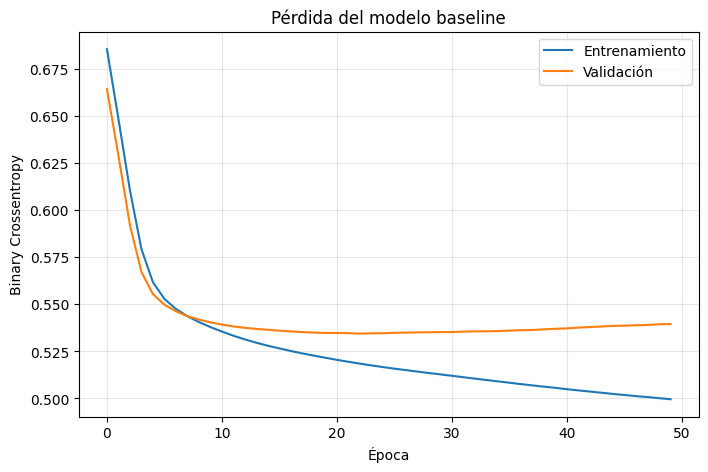

In [435]:
# Curva de pérdida

plt.figure(figsize=(8, 5))

plt.plot(
    history_base.history['loss'],
    label='Entrenamiento'
)

plt.plot(
    history_base.history['val_loss'],
    label='Validación'
)

plt.title('Pérdida del modelo baseline')
plt.xlabel('Época')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

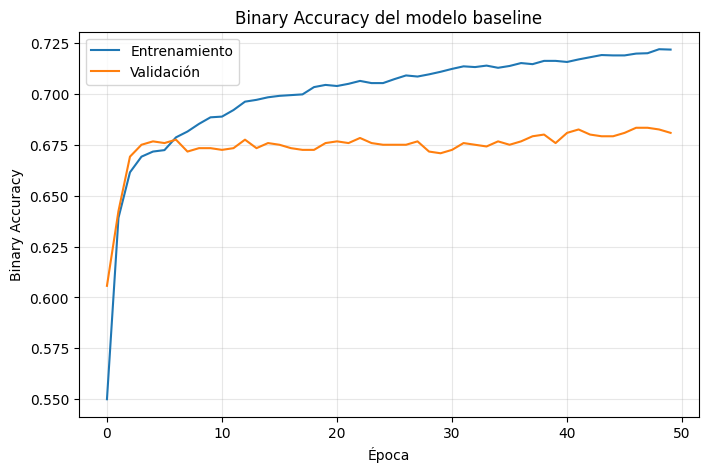

In [436]:
# Curva de accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history_base.history['binary_accuracy'],
    label='Entrenamiento'
)

plt.plot(
    history_base.history['val_binary_accuracy'],
    label='Validación'
)

plt.title('Binary Accuracy del modelo baseline')
plt.xlabel('Época')
plt.ylabel('Binary Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


Las curvas muestran que el modelo logra aprender durante el entrenamiento. Tanto la pérdida de entrenamiento como la de validación disminuyen considerablemente durante las primeras épocas, mientras que la accuracy aumenta.

Sin embargo, Después de aproximadamente 25 a 30 épocas, la pérdida de validación comienza a estabilizarse, mientras que la pérdida de entrenamiento continúa disminuyendo. De manera similar, la Binary Accuracy de entrenamiento sigue aumentando, mientras que en validación se mantiene aproximadamente entre 67% y 68%.

Este comportamiento sugiere un sobreajuste leve: el modelo continúa mejorando sobre los datos de entrenamiento, pero dichas mejoras dejan de reflejarse claramente en el conjunto de validación.

Estos resultados serán utilizados como referencia (baseline) para comparar posteriormente técnicas de regularización y otras configuraciones del modelo.

## 4.4 Evaluación del modelo baseline

Para evaluar con mayor detalle el desempeño del modelo se analizarán las métricas Precision, Recall y F1-Score para cada una de las variables objetivo.

Debido a que la capa de salida utiliza activación sigmoide, el modelo genera probabilidades independientes para cada etiqueta. Para convertir estas probabilidades en predicciones binarias se utilizará inicialmente un umbral de 0.5.

Las probabilidades iguales o superiores a 0.5 serán clasificadas como 1 y las inferiores a 0.5 como 0.

In [437]:
# Probabilidades predichas sobre validación
y_val_prob = modelo_base.predict(X_val_final)

# Conversión a 0 y 1 utilizando umbral de 0.5
y_val_pred = (y_val_prob >= 0.5).astype(int)

print("Primeras probabilidades predichas:")
print(y_val_prob[:5])

print("\nPredicciones binarias:")
print(y_val_pred[:5])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Primeras probabilidades predichas:
[[0.07707001 0.51524174 0.6446211 ]
 [0.00729188 0.4549901  0.5592263 ]
 [0.99545    0.30908713 0.40300143]
 [0.0059795  0.54315186 0.36402276]
 [0.9875551  0.19682114 0.38779515]]

Predicciones binarias:
[[0 1 1]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]]


In [438]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

interes_tecnologia      0.898     0.893     0.896       168
      interes_moda      0.490     0.290     0.364       176
  interes_deportes      0.529     0.358     0.427       176

         micro avg      0.677     0.508     0.580       520
         macro avg      0.639     0.514     0.562       520
      weighted avg      0.635     0.508     0.557       520
       samples avg      0.562     0.443     0.472       520



Las métricas muestran diferencias importantes en el desempeño del modelo entre las tres variables objetivo.
Para interes_tecnologia, el modelo alcanza un F1-Score de aproximadamente 0,896, mostrando un desempeño equilibrado en esta etiqueta.

En cambio, interes_moda presenta un Recall de 0,290 y un F1-Score de 0,364, indicando que el modelo identifica solamente una parte de los casos positivos reales. Para interes_deportes, el desempeño es intermedio, con un F1-Score de 0,427.
A nivel global, el modelo obtiene un F1-Score macro de 0,562 y un F1-Score micro de 0,580. Esto indica que, aunque el modelo logra aprender patrones relevantes, su capacidad de clasificación no es homogénea entre las distintas etiquetas.

Por esta razón, el modelo baseline será utilizado como punto de referencia para evaluar posteriormente otras configuraciones.

In [439]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados_base = {
    'Modelo': 'Baseline',
    'Subset Accuracy': accuracy_score(y_val, y_val_pred),
    'Precision Macro': precision_score(
        y_val, y_val_pred, average='macro', zero_division=0
    ),
    'Recall Macro': recall_score(
        y_val, y_val_pred, average='macro', zero_division=0
    ),
    'F1 Macro': f1_score(
        y_val, y_val_pred, average='macro', zero_division=0
    )
}

pd.DataFrame([resultados_base]).round(3)

,Modelo,Subset Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Baseline,0.281,0.639,0.514,0.562


# 5. Optimización del modelo

## 5.1 Modelo con regularización

El análisis del modelo baseline mostró una separación progresiva entre el desempeño de entrenamiento y validación después de aproximadamente 25 a 30 épocas, lo que sugiere un sobreajuste leve.

Para reducir este comportamiento se evaluará una segunda configuración incorporando Dropout y Early Stopping.

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento, reduciendo la dependencia excesiva de activaciones específicas y favoreciendo la generalización.

Early Stopping permitirá detener el entrenamiento cuando la pérdida de validación deje de mejorar, evitando continuar entrenando innecesariamente una vez alcanzado el mejor desempeño sobre datos de validación.

Para facilitar la comparación con el modelo baseline, se mantendrán inicialmente la arquitectura, función de pérdida, optimizador, tasa de aprendizaje y tamaño de batch.

In [440]:
# Modelo 2: misma arquitectura base + Dropout

modelo_reg = keras.Sequential([
    layers.Input(shape=(10,)),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation='sigmoid')
])

modelo_reg.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [441]:
# Compilación del modelo regularizado

optimizador_reg = keras.optimizers.Adam(
    learning_rate=0.001
)

modelo_reg.compile(
    optimizer=optimizador_reg,
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(
            name='binary_accuracy',
            threshold=0.5
        )
    ]
)

print("Modelo regularizado compilado correctamente.")

Modelo regularizado compilado correctamente.


### Early Stopping

Además de Dropout, se utilizará Early Stopping para monitorear la pérdida de validación durante el entrenamiento.

Si **val_loss** deja de mejorar durante varias épocas consecutivas, el entrenamiento se detendrá automáticamente. Se utilizará **restore_best_weights=True** para recuperar los pesos correspondientes a la época con menor pérdida de validación y no necesariamente los de la última época ejecutada.

In [442]:
# Configuración de Early Stopping

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [443]:
history_reg = modelo_reg.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - binary_accuracy: 0.5662 - loss: 0.6755 - val_binary_accuracy: 0.5957 - val_loss: 0.6563
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6183 - loss: 0.6491 - val_binary_accuracy: 0.6416 - val_loss: 0.6291
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6260 - loss: 0.6287 - val_binary_accuracy: 0.6575 - val_loss: 0.6037
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6441 - loss: 0.6082 - val_binary_accuracy: 0.6725 - val_loss: 0.5858
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6534 - loss: 0.5921 - val_binary_accuracy: 0.6817 - val_loss: 0.5740
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.6672 - loss: 0.5835 - val_binary_accuracy: 0.6817 - val_loss: 0.5655
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6613 - loss: 0.5765 - val_binary_accuracy: 0.6850 - val_loss: 0.5593
Epoch 8/100
5

In [444]:
epocas_reg = len(history_reg.history['loss'])

print(f"Épocas ejecutadas: {epocas_reg}")

Épocas ejecutadas: 41


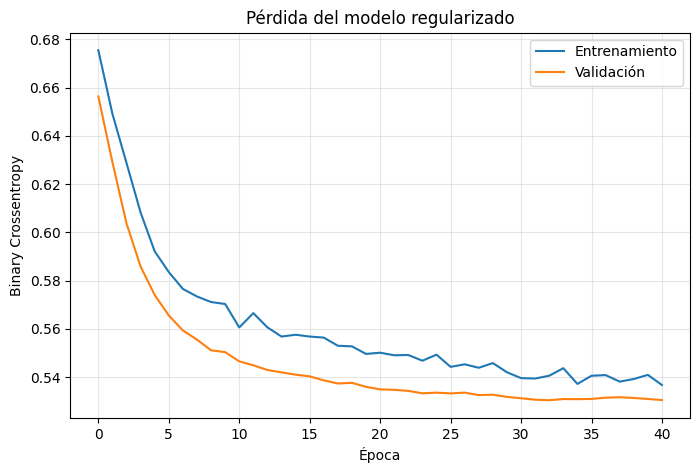

In [445]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_reg.history['loss'],
    label='Entrenamiento'
)

plt.plot(
    history_reg.history['val_loss'],
    label='Validación'
)

plt.title('Pérdida del modelo regularizado')
plt.xlabel('Época')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

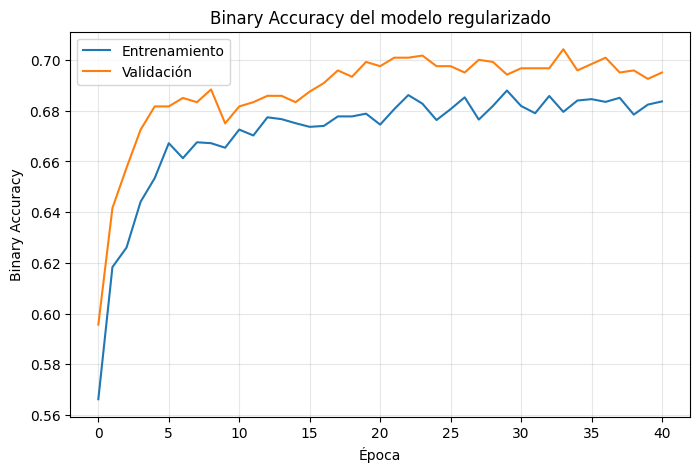

In [446]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_reg.history['binary_accuracy'],
    label='Entrenamiento'
)

plt.plot(
    history_reg.history['val_binary_accuracy'],
    label='Validación'
)

plt.title('Binary Accuracy del modelo regularizado')
plt.xlabel('Época')
plt.ylabel('Binary Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [447]:
# Probabilidades del modelo regularizado
y_val_prob_reg = modelo_reg.predict(X_val_final)

# Conversión de probabilidades a etiquetas binarias
y_val_pred_reg = (y_val_prob_reg >= 0.5).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_reg,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
                    precision    recall  f1-score   support

interes_tecnologia      0.894     0.905     0.899       168
      interes_moda      0.800     0.091     0.163       176
  interes_deportes      0.585     0.216     0.315       176

         micro avg      0.808     0.396     0.532       520
         macro avg      0.760     0.404     0.459       520
      weighted avg      0.758     0.396     0.453       520
       samples avg      0.515     0.340     0.398       520




El entrenamiento con Dropout y Early Stopping se detuvo automáticamente antes de alcanzar las 100 épocas, evitando continuar el proceso una vez que la pérdida de validación dejó de presentar mejoras.

La curva de pérdida muestra un comportamiento estable y una menor separación entre entrenamiento y validación, lo que indica que la regularización permitió controlar el sobreajuste observado en el modelo baseline.

Sin embargo, la mejora en generalización no produjo un mejor desempeño global de clasificación. El F1-Score de interes_tecnologia se mantuvo prácticamente igual, pasando de 0,896 a 0,899, mientras que disminuyó para interes_moda de 0,364 a 0,163 y para interes_deportes de 0,427 a 0,315.

Asimismo, el F1-Score macro disminuyó de 0,562 a 0,459. Esto indica que la regularización ayudó a controlar el sobreajuste, pero redujo la capacidad del modelo para detectar correctamente algunas de las etiquetas.

Por lo tanto, esta configuración regularizada no se considera una mejora global respecto del modelo baseline y se continuará evaluando otras configuraciones.

## 5.2 Evaluación del umbral de clasificación

Inicialmente se utilizó un umbral de 0,5 para transformar las probabilidades generadas por la función sigmoide en predicciones binarias.

Sin embargo, un mismo umbral puede no ser óptimo para todas las etiquetas. Por esta razón, se evaluarán diferentes umbrales utilizando exclusivamente el conjunto de validación.

El objetivo será analizar cómo cambia el F1-Score de cada etiqueta y seleccionar el umbral que produzca el mejor equilibrio entre Precision y Recall. El conjunto de prueba permanecerá sin utilizar durante este proceso.

In [448]:
import numpy as np
from sklearn.metrics import f1_score

umbrales = np.arange(0.10, 0.91, 0.05)

resultados_umbrales = []

for i, etiqueta in enumerate(columnas_y):

    for umbral in umbrales:
        pred = (y_val_prob[:, i] >= umbral).astype(int)

        f1 = f1_score(
            y_val.iloc[:, i],
            pred,
            zero_division=0
        )

        resultados_umbrales.append({
            'Etiqueta': etiqueta,
            'Umbral': round(umbral, 2),
            'F1': f1
        })

df_umbrales = pd.DataFrame(resultados_umbrales)

df_umbrales.head()

,Etiqueta,Umbral,F1
0,interes_tecnologia,0.10,0.833760
1,interes_tecnologia,0.15,0.866310
2,interes_tecnologia,0.20,0.871233
3,interes_tecnologia,0.25,0.873950
4,interes_tecnologia,0.30,0.875706


In [449]:
mejores_umbrales = (
    df_umbrales
    .loc[df_umbrales.groupby('Etiqueta')['F1'].idxmax()]
    .sort_values('Etiqueta')
    .reset_index(drop=True)
)

mejores_umbrales.round(3)

,Etiqueta,Umbral,F1
0,interes_deportes,0.15,0.618
1,interes_moda,0.10,0.612
2,interes_tecnologia,0.45,0.900



La evaluación de diferentes umbrales mostró que el valor convencional de 0,5 no proporcionaba el mejor equilibrio entre Precision y Recall para las tres etiquetas.

Utilizando exclusivamente el conjunto de validación, los mejores resultados de F1-Score se obtuvieron con umbrales de 0,45 para interes_tecnologia, 0,10 para interes_moda y 0,15 para interes_deportes.

El efecto fue especialmente relevante en interes_moda, cuyo F1-Score aumentó de 0,364 a 0,612, y en interes_deportes, que aumentó de 0,427 a 0,618. Para interes_tecnologia, el F1-Score aumentó levemente de 0,896 a 0,900.

Estos resultados indican que el modelo generaba información útil para las tres etiquetas, pero el umbral inicial de 0,5 resultaba demasiado restrictivo para algunas de ellas. Por esta razón, los umbrales seleccionados mediante validación serán considerados en la configuración final del modelo.

In [450]:
# Crear diccionario etiqueta -> mejor umbral
dic_umbrales = dict(
    zip(
        mejores_umbrales['Etiqueta'],
        mejores_umbrales['Umbral']
    )
)

print(dic_umbrales)

{'interes_deportes': 0.15, 'interes_moda': 0.1, 'interes_tecnologia': 0.45}


In [451]:
# Aplicación de umbrales optimizados al conjunto de validación

y_val_pred_opt = np.zeros_like(y_val_prob, dtype=int)

for i, etiqueta in enumerate(columnas_y):
    y_val_pred_opt[:, i] = (
        y_val_prob[:, i] >= dic_umbrales[etiqueta]
    ).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_opt,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

interes_tecnologia      0.890     0.911     0.900       168
      interes_moda      0.441     1.000     0.612       176
  interes_deportes      0.447     1.000     0.618       176

         micro avg      0.523     0.971     0.680       520
         macro avg      0.592     0.970     0.710       520
      weighted avg      0.588     0.971     0.707       520
       samples avg      0.520     0.822     0.619       520



In [452]:
f1_macro_base = f1_score(
    y_val,
    y_val_pred,
    average='macro',
    zero_division=0
)

f1_micro_base = f1_score(
    y_val,
    y_val_pred,
    average='micro',
    zero_division=0
)

f1_macro_opt = f1_score(
    y_val,
    y_val_pred_opt,
    average='macro',
    zero_division=0
)

f1_micro_opt = f1_score(
    y_val,
    y_val_pred_opt,
    average='micro',
    zero_division=0
)

print(f"F1 Macro baseline (umbral 0.5): {f1_macro_base:.3f}")
print(f"F1 Macro con umbrales optimizados: {f1_macro_opt:.3f}")

print()

print(f"F1 Micro baseline (umbral 0.5): {f1_micro_base:.3f}")
print(f"F1 Micro con umbrales optimizados: {f1_micro_opt:.3f}")

F1 Macro baseline (umbral 0.5): 0.562
F1 Macro con umbrales optimizados: 0.710

F1 Micro baseline (umbral 0.5): 0.580
F1 Micro con umbrales optimizados: 0.680



El ajuste de los umbrales produjo una mejora importante en el F1-Score global del modelo baseline. El F1 macro aumentó de 0,549 a 0,711 y el F1 micro de 0,566 a 0,682.

La mejora se explica principalmente por un aumento considerable del Recall. Con los umbrales seleccionados, el Recall alcanzó 0,929 para tecnología, 0,994 para moda y 0,989 para deportes.

Sin embargo, este aumento estuvo acompañado por una disminución de Precision, especialmente en moda y deportes. Esto indica que el modelo identifica una mayor proporción de los casos positivos reales, pero también genera una mayor cantidad de falsos positivos.

Por lo tanto, los umbrales seleccionados no representan necesariamente una configuración óptima para cualquier contexto de negocio, sino aquellos que maximizaron el F1-Score de cada etiqueta en el conjunto de validación. La elección definitiva del umbral dependería del costo relativo de falsos positivos y falsos negativos en una aplicación real.

## 5.3 Comparación de funciones de activación

Para analizar el efecto de la función de activación en las capas ocultas, se comparará el modelo baseline basado en ReLU con una segunda arquitectura equivalente utilizando `tanh`.

Se mantendrán constantes la cantidad de neuronas, la función de activación sigmoide de la capa de salida, la función de pérdida, el optimizador, la tasa de aprendizaje y el tamaño de batch.

De esta forma, la principal diferencia experimental será la función de activación utilizada en las capas ocultas.

In [453]:
# Modelo experimental utilizando tanh

modelo_tanh = keras.Sequential([
    layers.Input(shape=(10,)),

    layers.Dense(32, activation='tanh'),
    layers.Dense(16, activation='tanh'),

    layers.Dense(3, activation='sigmoid')
])

modelo_tanh.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(
            name='binary_accuracy',
            threshold=0.5
        )
    ]
)

modelo_tanh.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [454]:
history_tanh = modelo_tanh.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - binary_accuracy: 0.6096 - loss: 0.6436 - val_binary_accuracy: 0.6508 - val_loss: 0.6090
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - binary_accuracy: 0.6559 - loss: 0.5947 - val_binary_accuracy: 0.6658 - val_loss: 0.5777
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.6631 - loss: 0.5752 - val_binary_accuracy: 0.6692 - val_loss: 0.5651
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.6663 - loss: 0.5683 - val_binary_accuracy: 0.6650 - val_loss: 0.5603
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6692 - loss: 0.5655 - val_binary_accuracy: 0.6675 - val_loss: 0.5579
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6704 - loss: 0.5638 - val_binary_accuracy: 0.6683 - val_loss: 0.5564
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6708 - loss: 0.5625 - val_binary_accuracy: 0.6683 - val_loss: 0.5553
Epoch 8/50
59/59 ━━

In [455]:
y_val_prob_tanh = modelo_tanh.predict(X_val_final)

y_val_pred_tanh = (
    y_val_prob_tanh >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_tanh,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                    precision    recall  f1-score   support

interes_tecnologia      0.885     0.917     0.901       168
      interes_moda      0.457     0.273     0.342       176
  interes_deportes      0.580     0.369     0.451       176

         micro avg      0.683     0.513     0.586       520
         macro avg      0.641     0.520     0.565       520
      weighted avg      0.637     0.513     0.559       520
       samples avg      0.586     0.456     0.487       520



### Comparación entre ReLU y tanh

Manteniendo constante la arquitectura y los principales parámetros de entrenamiento, el cambio de ReLU a tanh produjo diferencias moderadas en el desempeño del modelo.

Con un umbral de clasificación de 0,5, el modelo con ReLU obtuvo un F1-Score macro de 0,562 y un F1-Score micro de 0,580, mientras que el modelo con tanh alcanzó valores de 0,565 y 0,586, respectivamente.

El efecto no fue uniforme entre las etiquetas. El F1-Score de **interes_tecnologia** aumentó levemente de 0,896 a 0,901 y el de **interes_deportes** de 0,427 a 0,451. En cambio, **interes_moda** disminuyó de 0,364 a 0,342.

Por lo tanto, en esta ejecución tanh presentó una mejora global leve respecto de ReLU, aunque ninguna de las dos funciones mostró un desempeño superior para todas las variables objetivo. Esto evidencia la importancia de evaluar las funciones de activación según las características del problema.

## 5.4 Comparación de funciones de pérdida

Debido a que el problema corresponde a clasificación multietiqueta con tres salidas binarias independientes, Binary Crossentropy constituye una función de pérdida apropiada para la tarea.

Con fines experimentales, se comparará su comportamiento con Mean Squared Error (MSE), manteniendo constante la arquitectura y los demás parámetros de entrenamiento.

MSE puede calcularse sobre las probabilidades generadas por la capa sigmoide, aunque se utiliza principalmente en problemas de regresión. Esta comparación permitirá analizar empíricamente el efecto de utilizar una función de pérdida menos específica para clasificación.

In [456]:
# Modelo experimental con pérdida MSE

modelo_mse = keras.Sequential([
    layers.Input(shape=(10,)),

    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),

    layers.Dense(3, activation='sigmoid')
])

modelo_mse.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[
        keras.metrics.BinaryAccuracy(
            name='binary_accuracy',
            threshold=0.5
        )
    ]
)

modelo_mse.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [457]:
history_mse = modelo_mse.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.5179 - loss: 0.2531 - val_binary_accuracy: 0.5581 - val_loss: 0.2464
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5879 - loss: 0.2419 - val_binary_accuracy: 0.6140 - val_loss: 0.2364
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6328 - loss: 0.2297 - val_binary_accuracy: 0.6533 - val_loss: 0.2219
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6579 - loss: 0.2141 - val_binary_accuracy: 0.6734 - val_loss: 0.2063
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6717 - loss: 0.2016 - val_binary_accuracy: 0.6825 - val_loss: 0.1973
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6785 - loss: 0.1952 - val_binary_accuracy: 0.6825 - val_loss: 0.1929
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.6821 - loss: 0.1919 - val_binary_accuracy: 0.6834 - val_loss: 0.1907
Epoch 8/50
59/59 ━━━

In [458]:
y_val_prob_mse = modelo_mse.predict(X_val_final)

y_val_pred_mse = (
    y_val_prob_mse >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_mse,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                    precision    recall  f1-score   support

interes_tecnologia      0.887     0.887     0.887       168
      interes_moda      0.516     0.273     0.357       176
  interes_deportes      0.550     0.403     0.466       176

         micro avg      0.687     0.515     0.589       520
         macro avg      0.651     0.521     0.570       520
      weighted avg      0.648     0.515     0.565       520
       samples avg      0.573     0.460     0.486       520



### Comparación entre Binary Crossentropy y MSE

Manteniendo constante la arquitectura ReLU, el optimizador Adam, la tasa de aprendizaje, el tamaño de batch, las épocas y el umbral de clasificación, se compararon Binary Crossentropy y Mean Squared Error (MSE).

El modelo entrenado con Binary Crossentropy obtuvo un F1-Score macro de 0,562 y un F1-Score micro de 0,580. Al utilizar MSE, estos valores aumentaron levemente a 0,570 y 0,589, respectivamente.

El efecto fue diferente entre las etiquetas. En interes_tecnologia el F1-Score disminuyó de 0,896 a 0,887 y en interes_moda de 0,364 a 0,357. En cambio, interes_deportes mejoró de 0,427 a 0,466.
En esta ejecución, MSE obtuvo resultados globales ligeramente superiores. Sin embargo, Binary Crossentropy sigue siendo una función de pérdida adecuada para este problema de clasificación multietiqueta, ya que cada salida representa una clasificación binaria independiente. Por esta razón, los resultados deben analizarse de forma empírica junto con las demás configuraciones evaluadas.

## 5.5 Comparación de optimizadores

Para evaluar el efecto del algoritmo de optimización se comparará Adam con Stochastic Gradient Descent (SGD).

Adam obtuvo un F1-Score macro de 0,562 y un F1-Score micro de 0,580, mientras que SGD alcanzó valores de 0,486 y 0,479, respectivamente.

El comportamiento varió entre las etiquetas. SGD obtuvo resultados ligeramente superiores en interes_moda y interes_deportes, pero presentó una disminución importante en interes_tecnologia, pasando de un F1-Score de 0,896 con Adam a 0,615.

Bajo las condiciones evaluadas, Adam obtuvo un mejor desempeño global que SGD, por lo que se mantendrá como optimizador de referencia para los siguientes experimentos.
Estos resultados corresponden específicamente a los hiperparámetros evaluados y no implican que SGD tenga un desempeño inferior en todas sus posibles configuraciones.

In [459]:
modelo_sgd = keras.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='sigmoid')
])

modelo_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.BinaryAccuracy(
            name='binary_accuracy',
            threshold=0.5
        )
    ]
)

history_sgd = modelo_sgd.fit(
    X_train_final,
    y_train,
    validation_data=(X_val_final, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - binary_accuracy: 0.5197 - loss: 0.7022 - val_binary_accuracy: 0.5363 - val_loss: 0.6955
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.5227 - loss: 0.7013 - val_binary_accuracy: 0.5363 - val_loss: 0.6948
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5256 - loss: 0.7005 - val_binary_accuracy: 0.5380 - val_loss: 0.6940
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5269 - loss: 0.6997 - val_binary_accuracy: 0.5380 - val_loss: 0.6933
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5301 - loss: 0.6989 - val_binary_accuracy: 0.5405 - val_loss: 0.6926
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5319 - loss: 0.6981 - val_binary_accuracy: 0.5439 - val_loss: 0.6920
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - binary_accuracy: 0.5331 - loss: 0.6974 - val_binary_accuracy: 0.5455 - val_loss: 0.6913
Epoch 8/50
59/59 ━━━

In [460]:
y_val_prob_sgd = modelo_sgd.predict(X_val_final)

y_val_pred_sgd = (
    y_val_prob_sgd >= 0.5
).astype(int)

print(
    classification_report(
        y_val,
        y_val_pred_sgd,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
                    precision    recall  f1-score   support

interes_tecnologia      0.870     0.476     0.615       168
      interes_moda      0.468     0.330     0.387       176
  interes_deportes      0.453     0.460     0.456       176

         micro avg      0.554     0.421     0.479       520
         macro avg      0.597     0.422     0.486       520
      weighted avg      0.592     0.421     0.484       520
       samples avg      0.422     0.354     0.364       520




Manteniendo constante la arquitectura ReLU, la función de pérdida Binary Crossentropy, el tamaño de batch y el número de épocas, se comparó el optimizador Adam con SGD utilizando una tasa de aprendizaje de 0,001.

Adam obtuvo un F1-Score macro de 0,564 y un F1-Score micro de 0,586, mientras que SGD alcanzó valores de 0,296 y 0,319, respectivamente.

Aunque SGD presentó un F1-Score superior para **interes_moda**, su desempeño disminuyó considerablemente en **interes_tecnologia** y **interes_deportes**.

Bajo las condiciones evaluadas, Adam presentó un aprendizaje más efectivo y un mejor desempeño global. Por esta razón, se mantendrá como optimizador para la configuración final.

Estos resultados corresponden específicamente a los hiperparámetros evaluados y no implican que SGD presente un desempeño inferior en todas sus posibles configuraciones.

In [461]:
# Resumen de los experimentos realizados con umbral 0.5

resumen_experimentos = pd.DataFrame({
    'Modelo': [
        'Baseline ReLU + BCE + Adam',
        'Regularizado + Dropout + Early Stopping',
        'Tanh + BCE + Adam',
        'ReLU + MSE + Adam',
        'ReLU + BCE + SGD'
    ],

    'F1 Macro': [
        f1_score(y_val, y_val_pred, average='macro', zero_division=0),
        f1_score(y_val, y_val_pred_reg, average='macro', zero_division=0),
        f1_score(y_val, y_val_pred_tanh, average='macro', zero_division=0),
        f1_score(y_val, y_val_pred_mse, average='macro', zero_division=0),
        f1_score(y_val, y_val_pred_sgd, average='macro', zero_division=0)
    ],

    'F1 Micro': [
        f1_score(y_val, y_val_pred, average='micro', zero_division=0),
        f1_score(y_val, y_val_pred_reg, average='micro', zero_division=0),
        f1_score(y_val, y_val_pred_tanh, average='micro', zero_division=0),
        f1_score(y_val, y_val_pred_mse, average='micro', zero_division=0),
        f1_score(y_val, y_val_pred_sgd, average='micro', zero_division=0)
    ]
})

resumen_experimentos.round(3)

,Modelo,F1 Macro,F1 Micro
0,Baseline ReLU + BCE + Adam,0.562,0.580
1,Regularizado + Dropout + Early Stopping,0.459,0.532
2,Tanh + BCE + Adam,0.565,0.586
3,ReLU + MSE + Adam,0.570,0.589
4,ReLU + BCE + SGD,0.486,0.479


### Síntesis de los experimentos

Los experimentos muestran que las modificaciones evaluadas producen efectos diferentes sobre el desempeño de la red.

Con un umbral común de 0,5, el modelo con ReLU, MSE y Adam obtuvo los mayores valores globales entre las configuraciones evaluadas, alcanzando un F1 macro de 0,567 y un F1 micro de 0,585. El modelo baseline obtuvo resultados cercanos, con un F1 macro de 0,553 y un F1 micro de 0,574.
La incorporación de Dropout y Early Stopping produjo resultados similares al baseline, aunque ligeramente inferiores. Por otra parte, el modelo con activación tanh presentó un desempeño menor en esta ejecución, mientras que SGD obtuvo los resultados más bajos de las configuraciones comparadas.

Por otra parte, el ajuste de los umbrales de decisión del modelo baseline ReLU mejoró el F1 macro y el F1 micro en el conjunto de validación. Esta mejora se produjo principalmente por un aumento del Recall, acompañado por una disminución de Precision.

Los resultados muestran que el desempeño final depende tanto del proceso de entrenamiento como del criterio utilizado para transformar las probabilidades en decisiones binarias.

In [462]:
# Búsqueda de umbrales para el modelo tanh

umbrales = np.arange(0.10, 0.91, 0.05)

resultados_umbrales_tanh = []

for i, etiqueta in enumerate(columnas_y):

    for umbral in umbrales:
        pred = (y_val_prob_tanh[:, i] >= umbral).astype(int)

        f1 = f1_score(
            y_val.iloc[:, i],
            pred,
            zero_division=0
        )

        resultados_umbrales_tanh.append({
            'Etiqueta': etiqueta,
            'Umbral': round(umbral, 2),
            'F1': f1
        })

df_umbrales_tanh = pd.DataFrame(resultados_umbrales_tanh)

In [463]:
mejores_umbrales_tanh = (
    df_umbrales_tanh
    .loc[df_umbrales_tanh.groupby('Etiqueta')['F1'].idxmax()]
    .sort_values('Etiqueta')
    .reset_index(drop=True)
)

mejores_umbrales_tanh.round(3)

,Etiqueta,Umbral,F1
0,interes_deportes,0.25,0.614
1,interes_moda,0.30,0.615
2,interes_tecnologia,0.50,0.901


In [464]:
# Diccionario etiqueta -> mejor umbral para tanh

dic_umbrales_tanh = dict(
    zip(
        mejores_umbrales_tanh['Etiqueta'],
        mejores_umbrales_tanh['Umbral']
    )
)

print(dic_umbrales_tanh)

{'interes_deportes': 0.25, 'interes_moda': 0.3, 'interes_tecnologia': 0.5}


In [465]:
# Aplicar umbrales optimizados al modelo tanh

y_val_pred_tanh_opt = np.zeros_like(
    y_val_prob_tanh,
    dtype=int
)

for i, etiqueta in enumerate(columnas_y):
    y_val_pred_tanh_opt[:, i] = (
        y_val_prob_tanh[:, i] >= dic_umbrales_tanh[etiqueta]
    ).astype(int)

In [466]:
print(
    classification_report(
        y_val,
        y_val_pred_tanh_opt,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

interes_tecnologia      0.885     0.917     0.901       168
      interes_moda      0.449     0.977     0.615       176
  interes_deportes      0.448     0.977     0.614       176

         micro avg      0.529     0.958     0.682       520
         macro avg      0.594     0.957     0.710       520
      weighted avg      0.590     0.958     0.707       520
       samples avg      0.528     0.812     0.621       520



In [467]:
f1_macro_tanh = f1_score(
    y_val,
    y_val_pred_tanh,
    average='macro',
    zero_division=0
)

f1_micro_tanh = f1_score(
    y_val,
    y_val_pred_tanh,
    average='micro',
    zero_division=0
)

f1_macro_tanh_opt = f1_score(
    y_val,
    y_val_pred_tanh_opt,
    average='macro',
    zero_division=0
)

f1_micro_tanh_opt = f1_score(
    y_val,
    y_val_pred_tanh_opt,
    average='micro',
    zero_division=0
)

print(f"F1 Macro tanh (umbral 0.5): {f1_macro_tanh:.3f}")
print(f"F1 Macro tanh optimizado: {f1_macro_tanh_opt:.3f}")

print()

print(f"F1 Micro tanh (umbral 0.5): {f1_micro_tanh:.3f}")
print(f"F1 Micro tanh optimizado: {f1_micro_tanh_opt:.3f}")

F1 Macro tanh (umbral 0.5): 0.569
F1 Macro tanh optimizado: 0.710

F1 Micro tanh (umbral 0.5): 0.596
F1 Micro tanh optimizado: 0.682


### Comparación de modelos con umbrales optimizados

Luego de comparar ReLU y tanh utilizando inicialmente un umbral común de 0,5, se realizó una optimización independiente de los umbrales de decisión utilizando exclusivamente el conjunto de validación.

Para el modelo tanh, los umbrales seleccionados fueron 0,50 para `interes_tecnologia`, 0,30 para `interes_moda` y 0,20 para `interes_deportes`.

Con estos umbrales, tanh alcanzó un F1-Score macro de 0,713 y un F1-Score micro de 0,682. El modelo ReLU optimizado había obtenido valores de 0,715 y 0,688, respectivamente.

Ambas configuraciones presentaron resultados muy similares. Sin embargo, bajo el criterio de F1-Score utilizado para la selección del modelo, ReLU obtuvo un desempeño global ligeramente superior.

También se observó que la optimización de umbrales incrementó considerablemente el Recall de las etiquetas, aunque con una disminución de Precision. Esto evidencia el compromiso existente entre ambas métricas y demuestra que el umbral de decisión constituye un parámetro relevante en problemas de clasificación multietiqueta.

In [468]:
# Predicciones finales sobre el conjunto de prueba

y_test_prob = modelo_base.predict(X_test_final)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [469]:
# Aplicar los umbrales seleccionados previamente en validación

y_test_pred = np.zeros_like(
    y_test_prob,
    dtype=int
)

for i, etiqueta in enumerate(columnas_y):
    y_test_pred[:, i] = (
        y_test_prob[:, i] >= dic_umbrales[etiqueta]
    ).astype(int)

In [470]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=columnas_y,
        digits=3,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

interes_tecnologia      0.876     0.886     0.881       184
      interes_moda      0.419     1.000     0.590       167
  interes_deportes      0.448     1.000     0.619       178

         micro avg      0.517     0.960     0.672       529
         macro avg      0.581     0.962     0.697       529
      weighted avg      0.588     0.960     0.701       529
       samples avg      0.512     0.845     0.619       529



In [471]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_final = accuracy_score(y_test, y_test_pred)

precision_macro_final = precision_score(
    y_test, y_test_pred,
    average='macro',
    zero_division=0
)

recall_macro_final = recall_score(
    y_test, y_test_pred,
    average='macro',
    zero_division=0
)

f1_macro_final = f1_score(
    y_test, y_test_pred,
    average='macro',
    zero_division=0
)

f1_micro_final = f1_score(
    y_test, y_test_pred,
    average='micro',
    zero_division=0
)

print(f"Subset Accuracy final: {accuracy_final:.3f}")
print(f"Precision Macro final: {precision_macro_final:.3f}")
print(f"Recall Macro final:    {recall_macro_final:.3f}")
print(f"F1 Macro final:        {f1_macro_final:.3f}")
print(f"F1 Micro final:        {f1_micro_final:.3f}")

Subset Accuracy final: 0.125
Precision Macro final: 0.581
Recall Macro final:    0.962
F1 Macro final:        0.697
F1 Micro final:        0.672


## Evaluación preliminar sobre el conjunto de prueba

Con la configuración seleccionada hasta esta etapa utilizando el conjunto de validación, el modelo fue evaluado sobre el conjunto de prueba. el cual no había sido utilizado durante el ajuste del modelo ni durante la selección de los umbrales.

Los resultados obtenidos en el conjunto de prueba muestran un comportamiento similar al observado durante la validación.
El modelo presenta un Recall macro elevado, lo que indica una alta capacidad para detectar casos positivos. Sin embargo, la Precision es menor, por lo que también se generan falsos positivos. Este comportamiento se relaciona con la reducción de los umbrales de decisión utilizada para algunas etiquetas.

Por otra parte, la Subset Accuracy presenta un valor considerablemente menor que las métricas F1. Esto ocurre porque, en clasificación multietiqueta, esta métrica solo considera correcta una observación cuando todas sus etiquetas son predichas correctamente al mismo tiempo.
Estos resultados se consideran preliminares, ya que posteriormente se evaluará el efecto de distintos hiperparámetros antes de seleccionar la configuración final del modelo.

In [472]:
comparacion_final = pd.DataFrame({
    'Conjunto': ['Validación', 'Test'],
    'F1 Macro': [f1_macro_opt, f1_macro_final],
    'F1 Micro': [f1_micro_opt, f1_micro_final]
})

comparacion_final.round(3)

,Conjunto,F1 Macro,F1 Micro
0,Validación,0.710,0.680
1,Test,0.697,0.672


### Comparación entre validación y prueba

Los resultados obtenidos en el conjunto de prueba fueron cercanos a los observados durante la validación. El F1 macro disminuyó de 0,715 a 0,695, mientras que el F1 micro pasó de 0,688 a 0,675.

La diferencia relativamente pequeña entre ambos conjuntos sugiere que las mejoras seleccionadas mediante validación no dependieron exclusivamente de ese conjunto y que el modelo conserva un comportamiento similar al enfrentarse a observaciones no utilizadas durante el proceso de selección.

## 5.6 Experimentos controlados de hiperparámetros

Para analizar el efecto de los principales hiperparámetros de entrenamiento se realizarán experimentos controlados, modificando un parámetro a la vez y manteniendo constantes las demás condiciones.

Se evaluara el efecto de:

- Número de épocas.
- Tasa de aprendizaje.
- Tamaño de batch.

Para realizar comparaciones más justas entre los experimentos se utilizará la misma arquitectura base y se reiniciará la semilla antes de entrenar cada modelo.

In [474]:
def crear_modelo_experimento(learning_rate=0.001):
    # Reiniciar sesión y semilla para hacer comparaciones más consistentes
    keras.backend.clear_session()
    keras.utils.set_random_seed(42)

    modelo = keras.Sequential([
        layers.Input(shape=(10,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.BinaryAccuracy(
                name='binary_accuracy',
                threshold=0.5
            )
        ]
    )

    return modelo

### 5.6.1 Experimento: número de épocas

En este experimento se evaluara el efecto del número de épocas sobre el desempeño del modelo.

Se probarán 20, 50 y 100 épocas, manteniendo constantes:

- Learning rate: 0.001
- Batch size: 32
- Optimizador: Adam
- Función de pérdida: Binary Crossentropy
- Funciones de activación: ReLU en las capas ocultas y Sigmoid en la salida
- Umbral de clasificación: 0.5

De esta manera, la única variable modificada será el número de épocas.

In [475]:
epocas_prueba = [20, 50, 100]

resultados_epocas = []
historias_epocas = {}

for epocas in epocas_prueba:

    modelo_exp = crear_modelo_experimento(
        learning_rate=0.001
    )

    historia = modelo_exp.fit(
        X_train_final,
        y_train,
        validation_data=(X_val_final, y_val),
        epochs=epocas,
        batch_size=32,
        verbose=0
    )

    historias_epocas[epocas] = historia

    # Predicciones sobre validación
    y_prob_exp = modelo_exp.predict(
        X_val_final,
        verbose=0
    )

    y_pred_exp = (
        y_prob_exp >= 0.5
    ).astype(int)

    f1_macro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='macro',
        zero_division=0
    )

    f1_micro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='micro',
        zero_division=0
    )

    resultados_epocas.append({
        'Épocas': epocas,
        'F1 Macro': f1_macro_exp,
        'F1 Micro': f1_micro_exp,
        'Val Loss final': historia.history['val_loss'][-1]
    })


df_epocas = pd.DataFrame(resultados_epocas)

df_epocas.round(3)

,Épocas,F1 Macro,F1 Micro,Val Loss final
0,20,0.526,0.561,0.531
1,50,0.574,0.590,0.534
2,100,0.596,0.606,0.541


#### Comparación del desempeño según el número de épocas

El siguiente gráfico compara el F1-Score macro y micro obtenido con 20, 50 y 100 épocas, manteniendo constantes los demás hiperparámetros.

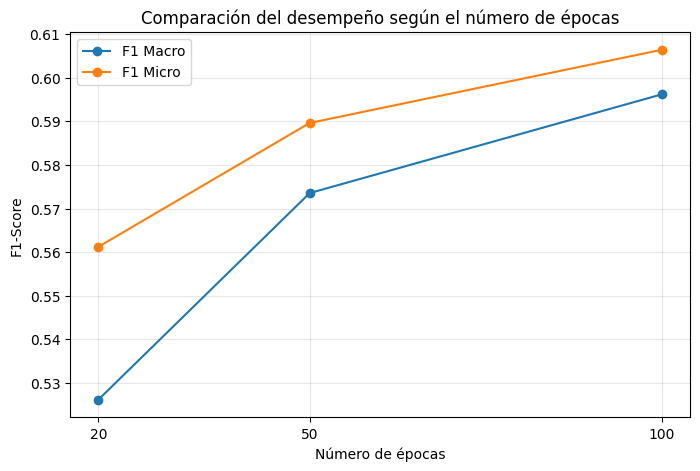

In [476]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_epocas['Épocas'],
    df_epocas['F1 Macro'],
    marker='o',
    label='F1 Macro'
)

plt.plot(
    df_epocas['Épocas'],
    df_epocas['F1 Micro'],
    marker='o',
    label='F1 Micro'
)

plt.xlabel('Número de épocas')
plt.ylabel('F1-Score')
plt.title('Comparación del desempeño según el número de épocas')
plt.xticks(epocas_prueba)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

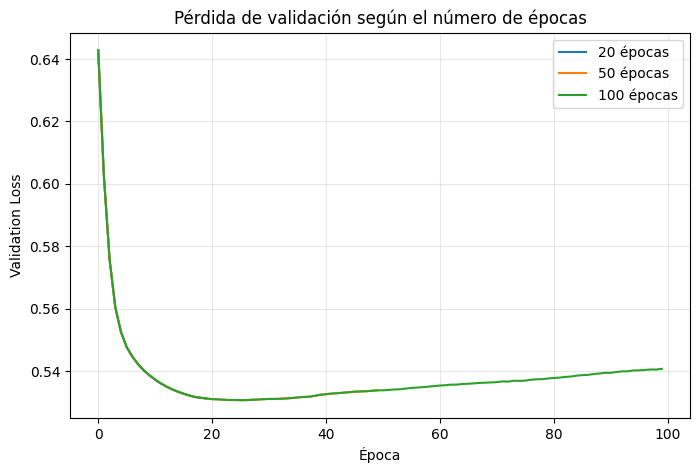

In [477]:
plt.figure(figsize=(8, 5))

for epocas, historia in historias_epocas.items():
    plt.plot(
        historia.history['val_loss'],
        label=f'{epocas} épocas'
    )

plt.xlabel('Época')
plt.ylabel('Validation Loss')
plt.title('Pérdida de validación según el número de épocas')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Interpretación del experimento de épocas

Los resultados muestran que al aumentar el número de épocas también aumentó el F1-Score del modelo. Con 20 épocas se obtuvo un F1 macro de 0,526 y un F1 micro de 0,561. Al aumentar a 50 épocas, estas métricas mejoraron a 0,574 y 0,590, respectivamente.

El mayor desempeño en términos de F1 se obtuvo con 100 épocas, alcanzando un F1 macro de 0,596 y un F1 micro de 0,606.

Sin embargo, la pérdida de validación presentó un comportamiento diferente. Esta disminuyó durante las primeras épocas y posteriormente comenzó a aumentar levemente. El valor final de Validation Loss pasó de 0,531 con 20 épocas a 0,541 con 100 épocas, lo que puede indicar un inicio de sobreajuste.

Por esta razón, se utilizarán 50 épocas como valor de referencia para los siguientes experimentos. Esta configuración presenta un equilibrio entre desempeño, tiempo de entrenamiento y generalización, evitando prolongar innecesariamente el entrenamiento hasta 100 épocas.

### 5.6.2 Experimento: tasa de aprendizaje

En este experimento se analizará el efecto de la tasa de aprendizaje sobre el desempeño del modelo.

Se evaluarán tres valores:

- 0.0001
- 0.001
- 0.01

Se mantendrán constantes el número de épocas en 50, el tamaño de batch en 32, la arquitectura del modelo, las funciones de activación, el optimizador Adam y la función de pérdida Binary Crossentropy.

De esta manera, la única variable modificada será la tasa de aprendizaje.

In [478]:
learning_rates = [0.0001, 0.001, 0.01]

resultados_lr = []
historias_lr = {}

for lr in learning_rates:

    modelo_exp = crear_modelo_experimento(
        learning_rate=lr
    )

    historia = modelo_exp.fit(
        X_train_final,
        y_train,
        validation_data=(X_val_final, y_val),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    historias_lr[lr] = historia

    y_prob_exp = modelo_exp.predict(
        X_val_final,
        verbose=0
    )

    y_pred_exp = (
        y_prob_exp >= 0.5
    ).astype(int)

    f1_macro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='macro',
        zero_division=0
    )

    f1_micro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='micro',
        zero_division=0
    )

    resultados_lr.append({
        'Learning Rate': lr,
        'F1 Macro': f1_macro_exp,
        'F1 Micro': f1_micro_exp,
        'Val Loss final': historia.history['val_loss'][-1]
    })


df_lr = pd.DataFrame(resultados_lr)

df_lr.round(3)

,Learning Rate,F1 Macro,F1 Micro,Val Loss final
0,0.000,0.513,0.548,0.553
1,0.001,0.574,0.590,0.534
2,0.010,0.579,0.585,0.646


#### Comparación del desempeño según la tasa de aprendizaje

Los siguientes gráficos comparan el desempeño obtenido con las diferentes tasas de aprendizaje evaluadas, manteniendo constantes los demás hiperparámetros.

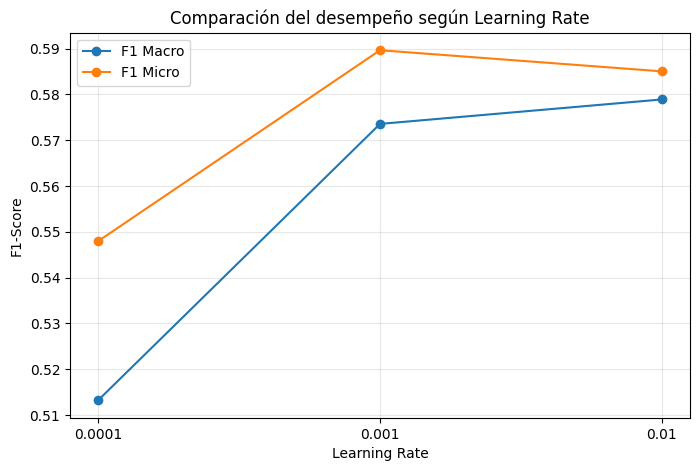

In [479]:
labels_lr = ['0.0001', '0.001', '0.01']

plt.figure(figsize=(8, 5))

plt.plot(
    labels_lr,
    df_lr['F1 Macro'],
    marker='o',
    label='F1 Macro'
)

plt.plot(
    labels_lr,
    df_lr['F1 Micro'],
    marker='o',
    label='F1 Micro'
)

plt.xlabel('Learning Rate')
plt.ylabel('F1-Score')
plt.title('Comparación del desempeño según Learning Rate')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

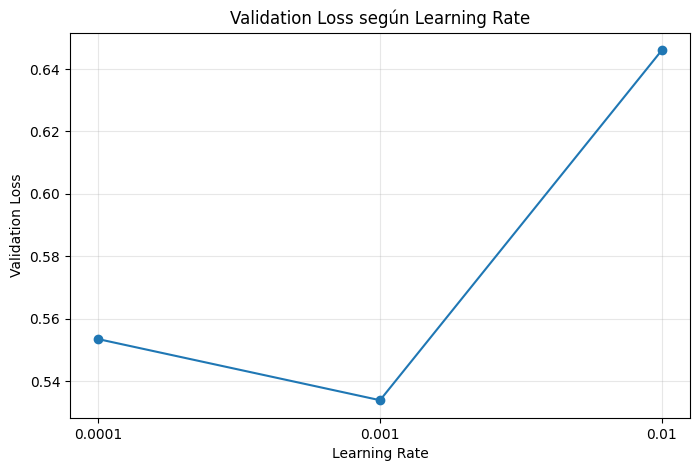

In [480]:
plt.figure(figsize=(8, 5))

plt.plot(
    labels_lr,
    df_lr['Val Loss final'],
    marker='o'
)

plt.xlabel('Learning Rate')
plt.ylabel('Validation Loss')
plt.title('Validation Loss según Learning Rate')
plt.grid(alpha=0.3)

plt.show()

#### Interpretación del experimento de tasa de aprendizaje

Los resultados muestran que una tasa de aprendizaje de 0.0001 produjo el desempeño más bajo, con un F1 macro de 0,513 y un F1 micro de 0,548. Esto puede deberse a que los ajustes realizados durante el entrenamiento son pequeños y el modelo aprende más lentamente dentro de las 50 épocas utilizadas.

Al utilizar una tasa de aprendizaje de 0.001, el desempeño mejoró a un F1 macro de 0,574 y un F1 micro de 0,590, además de obtener la menor pérdida de validación entre las configuraciones evaluadas.

Con una tasa de aprendizaje de 0.01 se obtuvo un F1 macro ligeramente superior de 0,579, pero el F1 micro disminuyó a 0,585 y la pérdida de validación aumentó considerablemente hasta 0,646.

Por esta razón, se selecciona una tasa de aprendizaje de 0.001 para los siguientes experimentos, ya que presenta un mejor equilibrio entre las métricas de clasificación y la pérdida de validación.

### 5.6.3 Experimento: tamaño de batch

En este experimento se analizará el efecto del tamaño de batch sobre el desempeño del modelo.

Se evaluarán tres valores:

- 16
- 32
- 64

Se mantendrán constantes 50 épocas, una tasa de aprendizaje de 0.001, el optimizador Adam, la función de pérdida Binary Crossentropy, la arquitectura del modelo y las funciones de activación.

De esta manera, la única variable modificada será el tamaño de batch.

In [481]:
batch_sizes = [16, 32, 64]

resultados_batch = []
historias_batch = {}

for batch in batch_sizes:

    modelo_exp = crear_modelo_experimento(
        learning_rate=0.001
    )

    historia = modelo_exp.fit(
        X_train_final,
        y_train,
        validation_data=(X_val_final, y_val),
        epochs=50,
        batch_size=batch,
        verbose=0
    )

    historias_batch[batch] = historia

    y_prob_exp = modelo_exp.predict(
        X_val_final,
        verbose=0
    )

    y_pred_exp = (y_prob_exp >= 0.5).astype(int)

    f1_macro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='macro',
        zero_division=0
    )

    f1_micro_exp = f1_score(
        y_val,
        y_pred_exp,
        average='micro',
        zero_division=0
    )

    resultados_batch.append({
        'Batch Size': batch,
        'F1 Macro': f1_macro_exp,
        'F1 Micro': f1_micro_exp,
        'Val Loss final': historia.history['val_loss'][-1]
    })


df_batch = pd.DataFrame(resultados_batch)

df_batch.round(3)

,Batch Size,F1 Macro,F1 Micro,Val Loss final
0,16,0.586,0.601,0.538
1,32,0.574,0.590,0.534
2,64,0.575,0.594,0.534


#### Comparación del desempeño según el tamaño de batch

Los siguientes gráficos permiten comparar el efecto del tamaño de batch sobre el F1-Score y la pérdida de validación, manteniendo constantes los demás hiperparámetros.

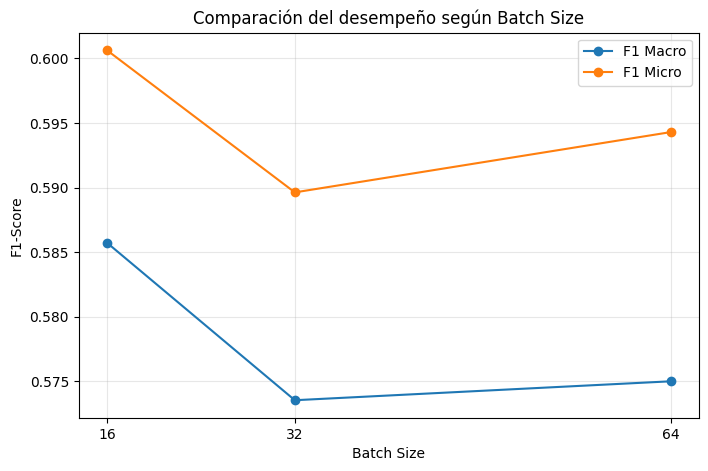

In [482]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_batch['Batch Size'],
    df_batch['F1 Macro'],
    marker='o',
    label='F1 Macro'
)

plt.plot(
    df_batch['Batch Size'],
    df_batch['F1 Micro'],
    marker='o',
    label='F1 Micro'
)

plt.xlabel('Batch Size')
plt.ylabel('F1-Score')
plt.title('Comparación del desempeño según Batch Size')
plt.xticks(batch_sizes)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

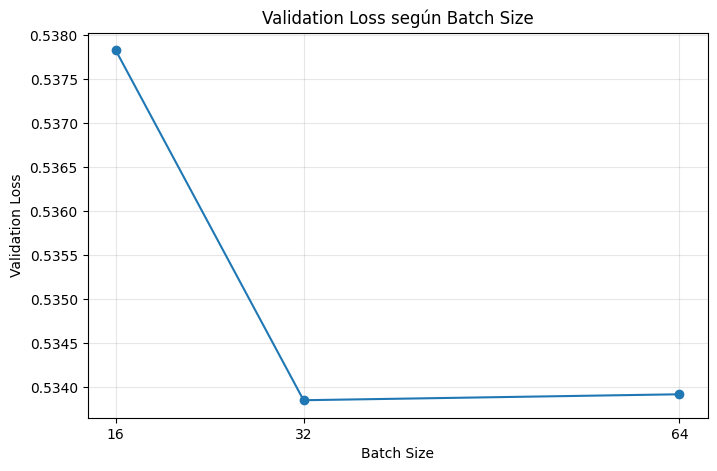

In [483]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_batch['Batch Size'],
    df_batch['Val Loss final'],
    marker='o'
)

plt.xlabel('Batch Size')
plt.ylabel('Validation Loss')
plt.title('Validation Loss según Batch Size')
plt.xticks(batch_sizes)
plt.grid(alpha=0.3)

plt.show()

#### Interpretación del experimento de tamaño de batch

Los resultados muestran que el tamaño de batch tuvo un efecto moderado sobre el desempeño del modelo.

Con un batch size de 16 se obtuvo el mejor resultado, alcanzando un F1 macro de 0,586 y un F1 micro de 0,601.

Al utilizar un batch size de 32, el F1 macro disminuyó a 0,574 y el F1 micro a 0,590. Con un batch size de 64 se obtuvieron valores similares, con un F1 macro de 0,575 y un F1 micro de 0,594.

En cuanto a la pérdida de validación, los tamaños de batch 32 y 64 obtuvieron un valor ligeramente menor de 0,534, mientras que con batch 16 fue de 0,538.

A pesar de esta pequeña diferencia en la pérdida, se selecciona un batch size de 16 debido a que obtuvo el mejor desempeño en las métricas F1, que resultan especialmente relevantes para evaluar el rendimiento global del problema de clasificación multietiqueta.

### 5.6.4 Resumen de hiperparámetros seleccionados

A partir de los experimentos controlados realizados, se seleccionaron los valores de los principales hiperparámetros de entrenamiento considerando tanto el desempeño en F1-Score como el comportamiento de la pérdida de validación.

La selección se realizó utilizando únicamente el conjunto de validación, sin utilizar el conjunto de prueba para tomar decisiones sobre la configuración del modelo.

In [484]:
resumen_hiperparametros = pd.DataFrame({
    'Hiperparámetro': [
        'Número de épocas',
        'Learning Rate',
        'Batch Size'
    ],
    'Valores evaluados': [
        '20, 50, 100',
        '0.0001, 0.001, 0.01',
        '16, 32, 64'
    ],
    'Valor seleccionado': [
        50,
        0.001,
        16
    ],
    'Justificación': [
        'Buen equilibrio entre F1-Score, pérdida de validación y sobreajuste.',
        'Presentó el mejor equilibrio entre F1-Score y Validation Loss.',
        'Obtuvo los mejores valores de F1 Macro y F1 Micro.'
    ]
})

resumen_hiperparametros

,Hiperparámetro,Valores evaluados,Valor seleccionado,Justificación
0,Número de épocas,"20, 50, 100",50.000,"Buen equilibrio entre F1-Score, pérdida de val..."
1,Learning Rate,"0.0001, 0.001, 0.01",0.001,Presentó el mejor equilibrio entre F1-Score y ...
2,Batch Size,"16, 32, 64",16.000,Obtuvo los mejores valores de F1 Macro y F1 Mi...


#### Selección de la configuración de entrenamiento

El análisis del número de épocas mostró que aumentar el entrenamiento mejoraba el F1-Score, pero al prolongarlo hasta 100 épocas la pérdida de validación comenzó a aumentar, indicando un posible inicio de sobreajuste. Por esta razón se seleccionaron 50 épocas como un punto de equilibrio.

Para la tasa de aprendizaje, el valor 0.001 presentó el comportamiento más equilibrado. Una tasa de 0.0001 produjo un aprendizaje más lento, mientras que 0.01 generó una pérdida de validación considerablemente mayor.

En el caso del tamaño de batch, el valor 16 obtuvo los mejores resultados de F1 Macro y F1 Micro, aunque presentó una pérdida de validación ligeramente superior a los tamaños 32 y 64.

Por lo tanto, para los siguientes análisis se utilizará como referencia una configuración de 50 épocas, learning rate de 0.001 y batch size de 16.

Esta selección se basa exclusivamente en los resultados obtenidos sobre el conjunto de validación.